<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/Neutrino003.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Seed 42: Final Low-k/High-k Ratio = 346715.5
Seed 101: Final Low-k/High-k Ratio = 511884.8
Seed 202: Final Low-k/High-k Ratio = 730607.4
Seed 303: Final Low-k/High-k Ratio = 449233.6
Seed 404: Final Low-k/High-k Ratio = 847943.2


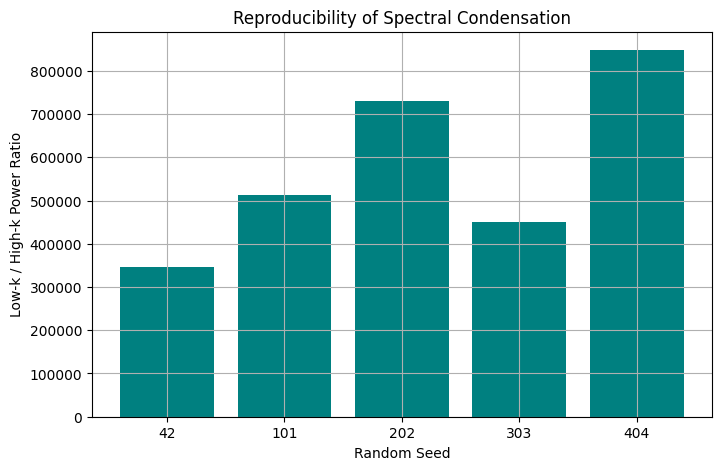

In [1]:
# 🔁 Multi-Seed Reproducibility Test
import numpy as np
from scipy.fft import fftn, fftfreq
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt

# Parameters
nx, ny, nz = 50, 50, 50
t_steps = 1500
dt = 0.01
kappa = 0.25
delta = 0.015
gamma_0 = 0.5
sigma = 0.08
seeds = [42, 101, 202, 303, 404]  # Random seeds to test

# Laplacian
def laplacian_3d(A):
    return (np.roll(A, 1, axis=0) + np.roll(A, -1, axis=0) +
            np.roll(A, 1, axis=1) + np.roll(A, -1, axis=1) +
            np.roll(A, 1, axis=2) + np.roll(A, -1, axis=2) - 6 * A)

# Power spectrum
def compute_power_spectrum(field):
    fft_A = fftn(field)
    power = np.abs(fft_A)**2
    kx = fftfreq(nx)
    ky = fftfreq(ny)
    kz = fftfreq(nz)
    kxx, kyy, kzz = np.meshgrid(kx, ky, kz, indexing='ij')
    k = np.sqrt(kxx**2 + kyy**2 + kzz**2)
    k_bins = np.linspace(0, np.max(k), 50)
    power_radial = np.zeros(len(k_bins) - 1)
    counts = np.zeros(len(k_bins) - 1)
    for i in range(len(k_bins) - 1):
        mask = (k >= k_bins[i]) & (k < k_bins[i+1])
        power_radial[i] = np.sum(power[mask])
        counts[i] = np.sum(mask)
    power_radial /= np.maximum(counts, 1)
    return k_bins[:-1], power_radial

# Run simulations
final_ratios = []
for seed in seeds:
    np.random.seed(seed)
    A = np.random.rand(nx, ny, nz) - 0.5
    for t in range(t_steps):
        xi = gaussian_filter(np.random.normal(0, sigma, A.shape), sigma=1.5)
        lap_A = gamma_0 * laplacian_3d(A)
        dA = -kappa * A + delta * A**2 + lap_A + xi
        A += dt * dA
    k_vals, power_radial = compute_power_spectrum(A)
    low_k = np.mean(power_radial[k_vals < 0.2])
    high_k = np.mean(power_radial[k_vals > 0.5])
    ratio = low_k / high_k if high_k > 0 else 0
    final_ratios.append(ratio)
    print(f"Seed {seed}: Final Low-k/High-k Ratio = {ratio:.1f}")

# Plot reproducibility
plt.figure(figsize=(8, 5))
plt.bar([str(s) for s in seeds], final_ratios, color='teal')
plt.ylabel('Low-k / High-k Power Ratio')
plt.xlabel('Random Seed')
plt.title('Reproducibility of Spectral Condensation')
plt.grid(True)
plt.show()
